In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [101]:
# Original Data
df_raw = pd.read_csv("CLT Weekly GPS onlinev1.xlsm - Week6Dump.csv")

# Preview
df_raw.head()

,Unnamed: 0,Name,Position Name,Date,Activity Name,Average Player Load (Session),Player Load Per Minute,Total Distance (y),Walking %,Maximum Velocity (mph),...,Velocity Band 1 Total Distance (y),Velocity Band 2 Total Distance (y),Velocity Band 3 Total Distance (y),Velocity Band 4 Total Distance (y),Velocity Band 5 Total Distance (y),Velocity Band 6 Total Distance (y),Velocity Band 7 Total Distance (y),Velocity Band 8 Total Distance (y),Relative HSD (>75%),Relative VHSD (>90%)
0,Kameron Manley46069,Kameron Manley,CB,2/16/2026,Win Wk6 Mon,312.4902,6.36115,2666.62077,31.81731,18.46964,...,1163.97636,671.71915,115.13561,142.77122,131.62729,214.7419,223.67673,0,862.93746,18.24147
1,Jameel Croft46069,Jameel Croft,CB,2/16/2026,Win Wk6 Mon,324.14523,6.5984,2749.89625,38.55391,18.26784,...,1352.85435,731.14612,157.88495,151.3014,207.49125,141.44794,4.21041,0,801.53107,4.21041
2,CJ Clinkscales46069,CJ Clinkscales,CB,2/16/2026,Win Wk6 Mon,347.14024,7.06649,3285.94505,33.71886,14.09528,...,1355.24936,1502.67938,118.3399,270.28652,40.1028,0,0,0,437.24848,0
3,DeQuinder Williams46069,DeQuinder Williams,CB,2/16/2026,Win Wk6 Mon,363.60799,7.40171,2692.37749,34.70761,18.71576,...,1167.32285,614.18417,209.03325,132.65529,121.94882,168.79921,241.22923,35.35652,909.0114,24.07043
4,Tyson Craig46069,Tyson Craig,CB,2/16/2026,Win Wk6 Mon,368.77928,7.50698,2710.90337,32.40091,19.15075,...,1173.4252,782.90683,177.84339,168.72266,280.46806,125.31715,0,0,954.73536,48.96107


In [102]:


df = pd.read_csv("CLT Weekly GPS onlinev1.xlsm - Week6Dump.csv")

# Drop empty rows
df = df.dropna()

# Convert relevant columns to numeric (force errors to NaN)
cols_to_convert = [
    "Average Player Load (Session)",
    "Relative VHSD (>90%)",
    "Accel + Decel Efforts"
]

for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows that failed conversion
df = df.dropna(subset=cols_to_convert)

# NOW create injury risk
df["injury_risk"] = (
    (df["Average Player Load (Session)"] > df["Average Player Load (Session)"].mean()) &
    (df["Relative VHSD (>90%)"] > df["Relative VHSD (>90%)"].mean()) &
    (df["Accel + Decel Efforts"] > df["Accel + Decel Efforts"].mean())
).astype(int)

print(df["injury_risk"].value_counts())

injury_risk
0    331
1     29
Name: count, dtype: int64


In [103]:
# Remove all columns that contain "Velocity"
df = df.loc[:, ~df.columns.str.contains("Velocity", case=False)]

print("Remaining columns:")
print(df.columns)

Remaining columns:
Index(['Unnamed: 0', 'Name', 'Position Name', 'Date', 'Activity Name',
       'Average Player Load (Session)', 'Player Load Per Minute',
       'Total Distance (y)', 'Walking %',
       'Acceleration B1-3 Average Efforts (Session) (Gen 2)',
       'Max Acceleration',
       'Deceleration B1-3 Average Efforts (Session) (Gen 2)',
       'Max Deceleration', 'Accel + Decel Efforts',
       'Explosive Efforts (IMA) (avg)', 'Relative HSD (>75%)',
       'Relative VHSD (>90%)', 'injury_risk'],
      dtype='str')


In [104]:
# Convert to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Drop bad date rows
df = df.dropna(subset=["Date"])

# Sort by date
df = df.sort_values(by="Date")

# Reset index (clean table)
df = df.reset_index(drop=True)

df = df.loc[:, ~df.columns.str.contains("Unnamed")]

In [105]:
df.columns = df.columns.str.strip()

In [106]:
df = df.loc[:, ~df.columns.str.contains("Velocity", case=False)]

In [107]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [108]:
df = df.dropna(subset=["Date"])

In [109]:
df = df.sort_values(by="Date")

In [110]:
df = df.reset_index(drop=True)

In [111]:
df.columns = df.columns.str.strip()

Below I decided to remove the velocity bands and the Unnamed column because they are a little redundant, all they do is break speed into different ranges. Also we already have different summaries similar to this such as total distance and high-speed distance. In much more simpilar terms, I am removing unnecessary details so the model focuses on meaningful variables.

In [112]:
#Cleaned Data
df.head()

,Name,Position Name,Date,Activity Name,Average Player Load (Session),Player Load Per Minute,Total Distance (y),Walking %,Acceleration B1-3 Average Efforts (Session) (Gen 2),Max Acceleration,Deceleration B1-3 Average Efforts (Session) (Gen 2),Max Deceleration,Accel + Decel Efforts,Explosive Efforts (IMA) (avg),Relative HSD (>75%),Relative VHSD (>90%),injury_risk
0,Kameron Manley,CB,2026-02-16,Win Wk6 Mon,312.49020,6.36115,2666.62077,31.81731,36,4.7306,26,-5.71275,62,11,862.93746,18.24147,0
1,Cody Taylor,OL,2026-02-16,Win Wk6 Mon,298.72519,6.08094,2090.68903,35.36228,29,3.65732,14,-3.39936,43,12,572.71433,0.00000,0
2,Jameel Croft,CB,2026-02-16,Win Wk6 Mon,324.14523,6.5984,2749.89625,38.55391,41,4.46068,21,-4.89195,62,7,801.53107,4.21041,0
3,CJ Clinkscales,CB,2026-02-16,Win Wk6 Mon,347.14024,7.06649,3285.94505,33.71886,11,3.82707,0,-1.79922,11,1,437.24848,0.00000,0
4,DeQuinder Williams,CB,2026-02-16,Win Wk6 Mon,363.60799,7.40171,2692.37749,34.70761,51,4.77093,26,-4.87082,77,21,909.0114,24.07043,1


# Chart Data Definitions

Average Player Load (Session) - Total mechanical stress accumulated during a session. It is calculated based on accelerometer data in 3 directions (forward, sideways, and vertical.) This is one of the best indicators of overall workload and fatigue.

Player Load Per Minute - Load divided by session duration. This measures intensity, not just total work.

Total Distance (y) - The total distance covered in yards. This is a basic volume metric. The only thing is that this does not cover for speed or intensity. But is why we have the two listed above.

Walking % - This is the percentage of time spent at low speed. This indicates recovery periods during different activities.

Acceleration B1-3 Average Efforts (Session)(Gen 2) - This is the number of accelerations in low-to-moderate intensity bands. This captures repeated effort movements.

Deceleration B1-3 Average Efforts (Session)(Gen 2) - This is the number of controlled slow-down movements. This is important because deceleration is actually more stressfull on the body than acceleration.

Max Acceleration - This is the highest acceleration reached in the session. This reflects explosive capability.

Max Deceleration - This is the highest rate of slowing down. This is important because of High injury risk due to joint stress.

Accel & Decel Efforts - The toatal number of accelerations and deceleration actions. This represents change-of-direction workload.

Explosive Efforts (IMA)(avg.) - This is the high-intensity movements measured by internal sensors (IMA = internal movement analysis). This captures sharp, powerful actions likes cuts, jumps, and bursts.

Relative HSD (>75%) - This is the distance covered at speeds above 75% of the players max speed (normalized). This also measures high-speed running relative to the athlete.

Relative VHSD (>90%) - The Distance covered above 90% of the athlete's max speed. This tracks sprint-level efforts (highest injury risk zone).

In [113]:
print(df.dtypes)

Name                                                              str
Position Name                                                     str
Date                                                   datetime64[us]
Activity Name                                                     str
Average Player Load (Session)                                 float64
Player Load Per Minute                                            str
Total Distance (y)                                                str
Walking %                                                         str
Acceleration B1-3 Average Efforts (Session) (Gen 2)               str
Max Acceleration                                                  str
Deceleration B1-3 Average Efforts (Session) (Gen 2)               str
Max Deceleration                                                  str
Accel + Decel Efforts                                           int64
Explosive Efforts (IMA) (avg)                                     str
Relative HSD (>75%) 

In [114]:
X = df.select_dtypes(include=["float64", "int64"]).drop("injury_risk", axis=1)
y = df["injury_risk"]

In [115]:
if len(df) == 0:
    raise ValueError("Dataset is empty after cleaning")
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [116]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Three classification models were selected to evaluate injury risk prediction based on player workload data: Logistic Regression, Random Forest, and Support Vector Machine (SVM). These models were chosen to represent different levels of model complexity and different approaches to classification.

# Logistic Regression

Logistic Regression predicts injury risk by estimating the probability that a given data point belongs to the high-risk category. It does this by forming a weighted combination of the input variables.

Each feature contributes to the prediction through a coefficient, which reflects how strongly that variable influences injury risk. For example, higher player load or increased acceleration efforts may increase the predicted probability of injury.

The model outputs a probability between 0 and 1, which is then converted into a classification based on a threshold. If the probability exceeds the threshold, the observation is classified as high risk.

In [117]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

print("Logistic Regression roc_auc_score:", roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1]))


Logistic Regression Accuracy: 0.9722222222222222
Logistic Regression roc_auc_score: 0.9873737373737375


# Random Forest

Random Forest predicts injury risk by evaluating a series of decision rules across many decision trees. Each tree splits the data based on feature thresholds, such as whether player load exceeds a certain value.

For example, one branch of a tree might evaluate whether high-speed distance is above a threshold, while another considers acceleration efforts. Each tree produces a classification, and the final prediction is determined by majority voting across all trees.

This approach allows the model to capture complex interactions between variables. Injury risk is often influenced by combinations of factors rather than a single variable, and Random Forest is effective at identifying these patterns.

In [118]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("Random Forest roc_auc_score:", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

Random Forest Accuracy: 0.9722222222222222
Random Forest roc_auc_score: 0.9785353535353536


# Support Vector Machine (SVM)

The Support Vector Machine predicts injury risk by determining a boundary that separates high-risk and low-risk data points in the feature space. The model identifies the optimal boundary that maximizes the distance between the two classes.

If the data is not linearly separable, the SVM uses a transformation to map the data into a higher-dimensional space where separation is possible. This allows the model to classify cases where the relationship between variables is more complex.

New data points are classified based on which side of the boundary they fall on.

In [119]:
svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM roc_auc_score:", roc_auc_score(y_test, svm.decision_function(X_test)))

SVM Accuracy: 0.9722222222222222
SVM roc_auc_score: 1.0


# Summary of Model Selection

The three models were selected to provide a range of perspectives on the classification problem. Logistic Regression offers a simple, interpretable baseline. Random Forest captures complex and nonlinear relationships in the data. The Support Vector Machine focuses on identifying optimal class boundaries.

By comparing these models, the analysis evaluates both the simplicity and complexity of approaches to determine which method best predicts injury risk based on the available data.

In [120]:
print("RF Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

RF Confusion Matrix:
 [[66  0]
 [ 2  4]]


In [121]:
print(df.columns)

Index(['Name', 'Position Name', 'Date', 'Activity Name',
       'Average Player Load (Session)', 'Player Load Per Minute',
       'Total Distance (y)', 'Walking %',
       'Acceleration B1-3 Average Efforts (Session) (Gen 2)',
       'Max Acceleration',
       'Deceleration B1-3 Average Efforts (Session) (Gen 2)',
       'Max Deceleration', 'Accel + Decel Efforts',
       'Explosive Efforts (IMA) (avg)', 'Relative HSD (>75%)',
       'Relative VHSD (>90%)', 'injury_risk'],
      dtype='str')


# Feature Importance Chart
The feature importance chart, generated using the Random Forest model, was used to quantify and rank the contribution of each variable to the prediction of injury risk. The chart displays features in order of importance based on how much they reduce prediction error across the model’s decision trees. This visualization was chosen because it provides a clear, model-based understanding of which variables are most influential in determining outcomes. Unlike the correlation heatmap, which only reflects linear relationships between variables, the feature importance chart captures nonlinear interactions and the actual impact of each feature within the predictive model. This allowed for a deeper interpretation of the results and helped identify the key workload metrics associated with injury risk.

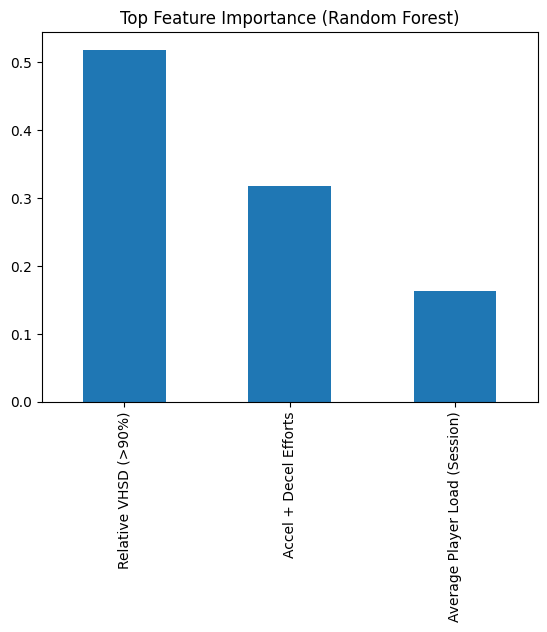

In [122]:
importances = rf.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure()
feat_imp.head(10).plot(kind="bar")
plt.title("Top Feature Importance (Random Forest)")
plt.show()

# Correlation Heat Map
The correlation heatmap was used to examine relationships between variables within the dataset by displaying the correlation coefficients between each pair of features in a color-coded matrix. Each cell in the heatmap represents the strength and direction of the relationship between two variables, allowing for quick identification of strong positive or negative correlations. This visualization was chosen because it provides an efficient way to understand the overall structure of the data and detect redundancy among variables. Identifying highly correlated features is important, as they may convey similar information and can impact model performance or interpretation. Using a correlation heatmap helped ensure that the dataset was well understood before applying predictive models.

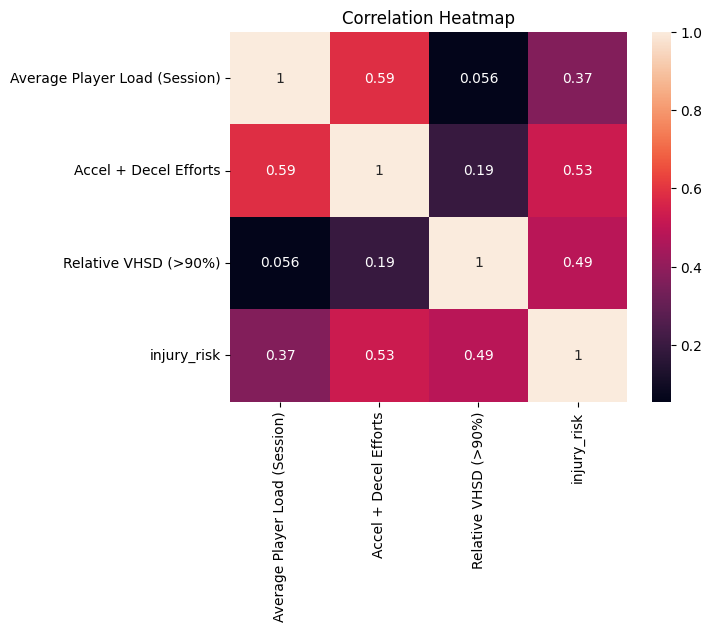

In [125]:
df_numeric = df.select_dtypes(include=["float64", "int64"])

plt.figure()
sns.heatmap(df_numeric.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()